# LLM02: Forward Propagation — Tensor Operations and Linear Layers

## Lab Overview

This lab covers the foundational operations of **forward propagation** in neural networks: tensors, matrix multiplication, `nn.Linear`, element-wise operations, `einsum`, and activation functions. These are the core tensor operations that underlie Transformer and LLM computations.

#### Recommended Hardware

AMD Ryzen™ AI Halo Processors (e.g., AI Max+ 395, AI Max 390)

#### Software Environment

OS: Ubuntu 24.04.3 LTS \
Install [AUP Learning Cloud](https://amdresearch.github.io/aup-learning-cloud/installation/quick-start.html?family=ryzen-ai&gpu=…). After installing AUP Learning Cloud, you will have a ROCm and PyTorch environment that is compatible with this notebook.

## Goals

By the end of this lab, you will:

- Understand PyTorch tensor creation, shapes, and device placement.
- Master matrix multiplication and its relationship to `nn.Linear`.
- Know when to use element-wise vs. matrix multiplication.
- Use `torch.einsum` for flexible tensor contractions and batch matrix multiplication.
- Compare common activation functions used in modern LLMs.

---


## 1. Environment Setup


In [2]:
# GPU Setup and Essential Imports
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F

# Configure device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
print(f"PyTorch version: {torch.__version__}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"GPU Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

Using device: cuda
PyTorch version: 2.9.1+rocm7.2.0.git7e1940d4
GPU: AMD Radeon(TM) 8060S Graphics
GPU Memory: 102.7 GB


## 2. Tensor Fundamentals

Tensors are the fundamental data structure in PyTorch and the building blocks of deep learning. Understanding tensors is crucial for working with neural networks and LLMs.


In [3]:
# 2.1 Creating Tensors and Basic Operations

print("=== Tensor Creation and Properties ===")

# Create tensors on the configured device (GPU if available, otherwise CPU)
x = torch.randn(10, 5, device=device)  # Input tensor: 10 samples, 5 features each
w = torch.randn(5, 3, requires_grad=True, device=device)  # Weight matrix: 5 inputs -> 3 outputs

print(f"Input tensor shape: {x.shape} | Device: {x.device}")
print(f"Weight tensor shape: {w.shape} | Device: {w.device}")
print(f"Weight requires gradients: {w.requires_grad}")

print(f"\nInput tensor (first 3 samples):\n{x[:3]}")
print(f"\nWeight tensor:\n{w}")

=== Tensor Creation and Properties ===
Input tensor shape: torch.Size([10, 5]) | Device: cuda:0
Weight tensor shape: torch.Size([5, 3]) | Device: cuda:0
Weight requires gradients: True

Input tensor (first 3 samples):
tensor([[ 0.6916, -1.1394, -0.9610,  0.6880, -0.2612],
        [ 0.2239,  0.1244, -0.3705, -0.6340, -0.4662],
        [-0.3231,  0.5012,  1.3863, -0.3282,  0.6264]], device='cuda:0')

Weight tensor:
tensor([[-0.7260, -2.3740, -0.5951],
        [-0.1618,  1.4596, -1.6561],
        [ 1.4496,  0.9252,  1.7093],
        [ 0.1563,  0.8440,  1.3834],
        [-0.4285, -0.0744, -0.8512]], device='cuda:0', requires_grad=True)


### Key Insight: This setup simulates a neural network layer

- Input: 10 samples with 5 features each
- Weights: Transform 5 input features to 3 output features
- This is the foundation of deep learning transformations!


In [4]:
# 2.2 Matrix Multiplication - The Heart of Neural Networks

print("=== Matrix Multiplication Methods ===")

# Method 1: @ operator (most commonly used)
y1 = x @ w  # Shape: (10, 5) @ (5, 3) -> (10, 3)
print(f"Method 1 (@): {x.shape} @ {w.shape} → {y1.shape}")
print(f"Result (first 3 samples):\n{y1[:3]}")

# Method 2: .matmul() method
y2 = x.matmul(w)
print(f"\nMethod 2 (.matmul()): {y2.shape}")
print(f"Results identical: {torch.allclose(y1, y2)}")

# Method 3: torch.matmul() function
y3 = torch.matmul(x, w)
print(f"\nMethod 3 (torch.matmul()): {y3.shape}")
print(f"All methods identical: {torch.allclose(y1, y3)}")

=== Matrix Multiplication Methods ===
Method 1 (@): torch.Size([10, 5]) @ torch.Size([5, 3]) → torch.Size([10, 3])
Result (first 3 samples):
tensor([[-1.4914, -3.5939,  1.0068],
        [-0.6190, -1.1932, -1.4528],
        [ 1.8435,  2.4577,  0.7447]], device='cuda:0',
       grad_fn=<SliceBackward0>)

Method 2 (.matmul()): torch.Size([10, 3])
Results identical: True

Method 3 (torch.matmul()): torch.Size([10, 3])
All methods identical: True


### Understanding the Transformation

- Each of 10 samples (rows) gets transformed
- From 5 input features to 3 output features
- This is exactly what happens in neural network layers!
- Essential for: Linear layers, Attention mechanisms, LLM computations


In [5]:
# 2.3 PyTorch Linear Layers - Neural Network Building Blocks

print("=== PyTorch Linear Layer ===")

# Create linear layer and move to GPU
linear = torch.nn.Linear(5, 3, bias=False).to(device)
print(f"Linear layer weight shape: {linear.weight.shape}")
print(f"Linear layer on device: {linear.weight.device}")
print(f"Linear layer bias: {linear.bias}")

# Set the weights to match our manual example
with torch.no_grad():
    linear.weight.copy_(w.T)  # Note: Linear layers store weights transposed
print(f"\nOriginal weight matrix w:\n{w}")
print(f"Linear layer weight (w^T):\n{linear.weight}")

# Apply the linear transformation
y_linear = linear(x)
print(f"\nLinear layer output shape: {y_linear.shape}")
print(f"First 3 outputs:\n{y_linear[:3]}")

# Verify equivalence
print(f"\nManual matmul vs Linear layer: {torch.allclose(y3, y_linear)}")

=== PyTorch Linear Layer ===
Linear layer weight shape: torch.Size([3, 5])
Linear layer on device: cuda:0
Linear layer bias: None

Original weight matrix w:
tensor([[-0.7260, -2.3740, -0.5951],
        [-0.1618,  1.4596, -1.6561],
        [ 1.4496,  0.9252,  1.7093],
        [ 0.1563,  0.8440,  1.3834],
        [-0.4285, -0.0744, -0.8512]], device='cuda:0', requires_grad=True)
Linear layer weight (w^T):
Parameter containing:
tensor([[-0.7260, -0.1618,  1.4496,  0.1563, -0.4285],
        [-2.3740,  1.4596,  0.9252,  0.8440, -0.0744],
        [-0.5951, -1.6561,  1.7093,  1.3834, -0.8512]], device='cuda:0',
       requires_grad=True)

Linear layer output shape: torch.Size([10, 3])
First 3 outputs:
tensor([[-1.4914, -3.5939,  1.0068],
        [-0.6190, -1.1932, -1.4528],
        [ 1.8435,  2.4577,  0.7447]], device='cuda:0',
       grad_fn=<SliceBackward0>)

Manual matmul vs Linear layer: True


### What `nn.Linear` provides

- The building blocks of neural networks
- Used in: MLPs, Transformers, LLM projection layers
- Efficiently implement: y = xW^T + b  
  (PyTorch stores `nn.Linear.weight` with shape `[out_features, in_features]`)
- Handle batching automatically


## 3. Element-wise Multiplication (Hadamard Product)

Element-wise multiplication applies the same operation independently to every position of two tensors with the **same shape** (or shapes that are **broadcastable**). In PyTorch you can use `*`, `.mul()`, or `torch.mul()`.

**Definition (Hadamard product):** for tensors $A, B \in \mathbb{R}^{m \times n}$,
$(A \odot B)_{ij} = A_{ij} \times B_{ij}$.

**Why it matters**

- Used in gating (for example in SwiGLU), attention masks, and learned rescaling terms in normalization layers.
- Preserves shape, dtype, and device of the inputs.
- **Key distinction**: `*` is element-wise; `@` / `matmul` is linear-algebraic matrix multiplication.


In [6]:
# element wise multiplication

print("Original weight matrix:")
print(w)

z = w * w
print("\nElement-wise square (same shape):")
print(z)
print(f"w shape: {w.shape}, z shape: {z.shape}")

row, col = 3, 2
print(f"\nCheck one element: w[{row}, {col}]^2 = {w[row, col].item() ** 2:.6f}")
print(f"Stored result: z[{row}, {col}] = {z[row, col].item():.6f}")

Original weight matrix:
tensor([[-0.7260, -2.3740, -0.5951],
        [-0.1618,  1.4596, -1.6561],
        [ 1.4496,  0.9252,  1.7093],
        [ 0.1563,  0.8440,  1.3834],
        [-0.4285, -0.0744, -0.8512]], device='cuda:0', requires_grad=True)

Element-wise square (same shape):
tensor([[5.2702e-01, 5.6357e+00, 3.5413e-01],
        [2.6190e-02, 2.1304e+00, 2.7426e+00],
        [2.1014e+00, 8.5597e-01, 2.9217e+00],
        [2.4419e-02, 7.1233e-01, 1.9137e+00],
        [1.8361e-01, 5.5297e-03, 7.2456e-01]], device='cuda:0',
       grad_fn=<MulBackward0>)
w shape: torch.Size([5, 3]), z shape: torch.Size([5, 3])

Check one element: w[3, 2]^2 = 1.913680
Stored result: z[3, 2] = 1.913680


Here is a tiny example showing broadcasting in element-wise multiplication.


In [7]:
print("\nBroadcasting example:")
v = torch.tensor([1.0, 2.0, 3.0], device=w.device)  # shape: [3]
m = torch.ones(2, 3, device=w.device)  # shape: [2, 3]

# PyTorch automatically expands v from [3] to [2, 3] to match m.
result = m * v

print("v shape:", v.shape)
print("m shape:", m.shape)
print("result shape:", result.shape)
print(result)


Broadcasting example:
v shape: torch.Size([3])
m shape: torch.Size([2, 3])
result shape: torch.Size([2, 3])
tensor([[1., 2., 3.],
        [1., 2., 3.]], device='cuda:0')


## 4. nn.Linear Stacking and Multi-Dimensional Tensors

Neural networks are built by **stacking** multiple linear layers. `nn.Linear` also transparently handles multi-dimensional input tensors — it always transforms the **last dimension**.

**Key points:**

- Stacking: `y = layer2(layer1(x))` — composing linear transformations
- Multi-dim: Input `[batch, ..., in_features]` → Output `[batch, ..., out_features]`
- In Transformers, inputs are typically `[batch, seq_len, hidden_dim]`


In [8]:
# 4.1 Stacking nn.Linear layers

m1 = nn.Linear(20, 30).to(device)
m2 = nn.Linear(30, 40).to(device)
x = torch.randn(128, 20, device=device)

y1 = m1(x)  # [128, 20] → [128, 30]
y2 = m2(y1)  # [128, 30] → [128, 40]

print(f"Input shape:      {x.shape}")
print(f"After layer 1:    {y1.shape}")
print(f"After layer 2:    {y2.shape}")
print(f"Parameters m1:    {sum(p.numel() for p in m1.parameters()):,}")
print(f"Parameters m2:    {sum(p.numel() for p in m2.parameters()):,}")
print("\nNote: stacking linear layers without an activation is still just one overall linear transformation.")

Input shape:      torch.Size([128, 20])
After layer 1:    torch.Size([128, 30])
After layer 2:    torch.Size([128, 40])
Parameters m1:    630
Parameters m2:    1,240

Note: stacking linear layers without an activation is still just one overall linear transformation.


In [9]:
# 4.2 Multi-dimensional tensor through nn.Linear
# nn.Linear transforms only the LAST dimension, leaving others untouched.
# This is critical for Transformers: [batch, seq_len, hidden_dim]

x_3d = torch.randn(4, 8, 20, device=device)  # [batch=4, seq_len=8, features=20]
y_3d = m1(x_3d)  # → [4, 8, 30]
print(f"3D input:  {x_3d.shape}  →  output: {y_3d.shape}")

x_4d = torch.randn(2, 4, 8, 20, device=device)  # Even higher-dim works
y_4d = m1(x_4d)
print(f"4D input:  {x_4d.shape}  →  output: {y_4d.shape}")

print("\nnn.Linear always applies to the last dimension — perfect for Transformer hidden states.")

3D input:  torch.Size([4, 8, 20])  →  output: torch.Size([4, 8, 30])
4D input:  torch.Size([2, 4, 8, 20])  →  output: torch.Size([2, 4, 8, 30])

nn.Linear always applies to the last dimension — perfect for Transformer hidden states.


## 5. Einstein Summation (`einsum`) and Batch Matrix Multiplication

`torch.einsum` is a compact, expressive way to write any tensor contraction. Many PyTorch operations (matmul, bmm, trace, outer product) can be expressed as a single `einsum` call.

**Notation:** The subscript string names each dimension. Repeated indices are summed over (contracted), and the output indices are listed after `->`.

| Operation       | einsum string    | Equivalent          |
| --------------- | ---------------- | ------------------- |
| Matrix multiply | `'ik,kj->ij'`    | `A @ B`             |
| Batch matmul    | `'bik,bkj->bij'` | `torch.bmm(A, B)`   |
| Inner product   | `'i,i->'`        | `torch.dot(a, b)`   |
| Trace           | `'ii->'`         | `torch.trace(A)`    |
| Outer product   | `'i,j->ij'`      | `torch.outer(a, b)` |

**Batch Matrix Multiplication** is especially important for Multi-Head Attention, where we compute attention for each head independently in parallel.


In [10]:
# 5.1 einsum basics — matrix multiplication
A = torch.randn(3, 4)
B = torch.randn(4, 5)

C_matmul = A @ B
C_einsum = torch.einsum("ik,kj->ij", A, B)
print(f"A @ B  shape: {C_matmul.shape}")
print(f"Match: {torch.allclose(C_matmul, C_einsum)}")

# 5.2 Batch matrix multiplication (key for multi-head attention)
# Suppose we have num_heads=8 independent Q·K^T computations
num_heads, seq_len, head_dim = 8, 16, 64
Q = torch.randn(num_heads, seq_len, head_dim)
K = torch.randn(num_heads, seq_len, head_dim)

# Method 1: torch.bmm (requires 3-D inputs)
attn_bmm = torch.bmm(Q, K.transpose(-2, -1))  # [8, 16, 16]

# Method 2: einsum
# Here h = num_heads, s/t = sequence positions, d = head_dim
attn_einsum = torch.einsum("hsd,htd->hst", Q, K)  # same result

print(f"\nBatch matmul shape: {attn_bmm.shape}")
print(f"bmm == einsum: {torch.allclose(attn_bmm, attn_einsum)}")

# 5.3 Trace and outer product
M = torch.randn(4, 4)
print(f"\nTrace (einsum): {torch.einsum('ii->', M):.4f}")
print(f"Trace (torch):  {torch.trace(M):.4f}")

a = torch.tensor([1.0, 2.0, 3.0])
b = torch.tensor([4.0, 5.0])
print(f"Outer product:\n{torch.einsum('i,j->ij', a, b)}")

A @ B  shape: torch.Size([3, 5])
Match: True

Batch matmul shape: torch.Size([8, 16, 16])
bmm == einsum: True

Trace (einsum): -3.3956
Trace (torch):  -3.3956
Outer product:
tensor([[ 4.,  5.],
        [ 8., 10.],
        [12., 15.]])


## 6. Activation Functions

Without activation functions, stacking multiple `nn.Linear` layers collapses into a **single** linear transformation ($W_2 W_1 x = W' x$). Activations introduce **non-linearity**, enabling networks to approximate any function.

### Common activations in LLMs

| Activation       | Formula             | Used in                                               |
| ---------------- | ------------------- | ----------------------------------------------------- |
| **ReLU**         | $\max(0, x)$        | Classic activation in early neural networks / CNNs    |
| **GELU**         | $x \cdot \Phi(x)$   | BERT, GPT-style Transformers                          |
| **SiLU / Swish** | $x \cdot \sigma(x)$ | Used inside SwiGLU-style FFNs in LLaMA, Mistral, Qwen |

Modern LLMs (LLaMA, Mistral, Qwen) often use **SwiGLU**, a gated feed-forward variant where one projection is activated by SiLU and then multiplied element-wise with another projection.


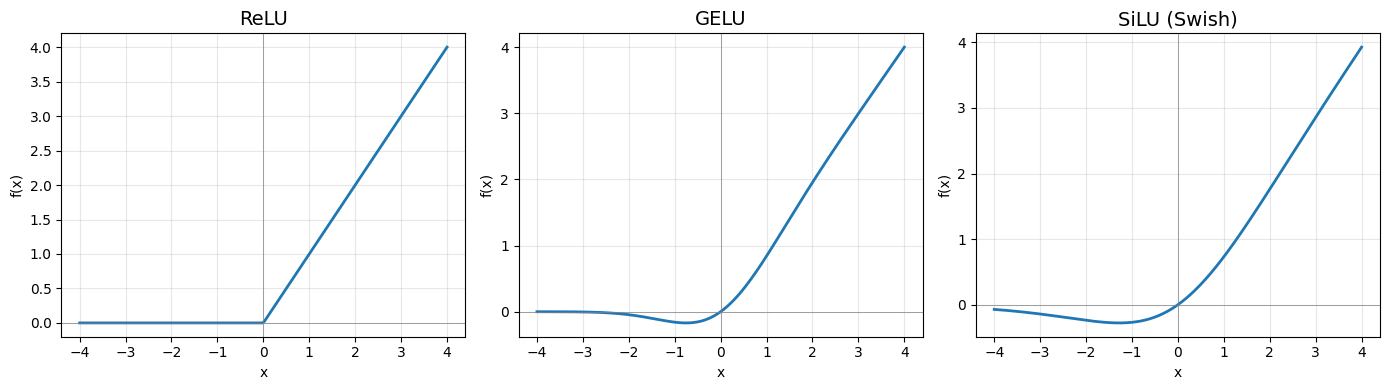

x = -1.0
  ReLU:  0.0000
  GELU:  -0.1587
  SiLU:  -0.2689

Note: ReLU kills all negative inputs. GELU and SiLU allow small negative values through.


In [11]:
import matplotlib.pyplot as plt
import torch.nn.functional as F

x = torch.linspace(-4, 4, 200)

activations = {
    "ReLU": F.relu(x),
    "GELU": F.gelu(x),
    "SiLU (Swish)": F.silu(x),
}

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, (name, y) in zip(axes, activations.items()):
    ax.plot(x.numpy(), y.numpy(), linewidth=2)
    ax.set_title(name, fontsize=14)
    ax.axhline(0, color="gray", linewidth=0.5)
    ax.axvline(0, color="gray", linewidth=0.5)
    ax.set_xlabel("x")
    ax.set_ylabel("f(x)")
    ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Quick numerical comparison at a negative value
val = torch.tensor(-1.0)
print(f"x = {val.item()}")
print(f"  ReLU:  {F.relu(val).item():.4f}")
print(f"  GELU:  {F.gelu(val).item():.4f}")
print(f"  SiLU:  {F.silu(val).item():.4f}")
print("\nNote: ReLU kills all negative inputs. GELU and SiLU allow small negative values through.")

## Conclusions

### Technical Concepts Learned

- **Tensor Fundamentals**: Creating tensors, understanding shapes, devices, and basic properties
- **Matrix Multiplication**: Three equivalent methods (`@`, `.matmul()`, `torch.matmul()`) and their connection to neural network layers
- **nn.Linear**: How PyTorch implements `y = xW^T + b`, weight transposition, and automatic batching
- **Element-wise Operations**: Hadamard product (`*`) vs. matrix multiplication (`@`)
- **nn.Linear Stacking**: Composing layers and processing multi-dimensional tensors
- **einsum**: Flexible Einstein summation for matrix multiply, batched operations, and trace
- **Batch Matrix Multiplication**: `torch.bmm` and batched `matmul` for parallel head computation
- **Activation Functions**: ReLU, GELU, SiLU/Swish and their roles in Transformer FFN layers

### What's Next

- **LLM03**: Autograd, backpropagation, and training loops
- **LLM04**: Tokenization and positional encoding
- **LLM05**: Normalization (RMSNorm) and FFN architectures

### Experiment Further

- Try `torch.einsum('bsh,bsh->bs', x, x)` to compute per-position dot products
- Compare `torch.bmm` vs `torch.einsum` speed on large batches
- Replace ReLU with SiLU in a simple 2-layer MLP and observe output differences


---

Copyright (C) 2025 Advanced Micro Devices, Inc. All rights reserved. Portions of this file consist of AI-generated content.
SPDX-License-Identifier: MIT
